## 1. Importing libraries and loading the CSV file


Here, we are importing `pandas` for working with our data, and `numpy`, `seaborn`, and `matplotlib` for making simple charts.
We read the `UScomments.csv` file. After loading it, we check if there are any blank cells (missing values) and delete those rows so they don't cause any errors.


### **What we are doing here:**
First, I'm setting up our Python environment by importing the packages we need: `pandas` for working with tables, `numpy` for math/arrays, and `seaborn` / `matplotlib` for creating charts.
Then, we load our main dataset of US YouTube comments (`UScomments.csv`). I also ran a quick check for missing values and dropped them so they don't cause issues in our analysis later!


### **Overview**
In this section, we set up our analytical environment by importing essential Python data science packages: `pandas` for data manipulation, `numpy` for scientific computing, and `seaborn` / `matplotlib` for visualization. We load the YouTube comments dataset (`UScomments.csv`) and run quality checks to locate and handle missing data.


In [1]:
### lets import all the necessary packages !

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
comments = pd.read_csv(r'./UScomments.csv' , on_bad_lines='skip')

C:\Users\SATYAJIT NAYAK\AppData\Local\Temp\ipykernel_11544\1834799741.py:1: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  comments = pd.read_csv(r'./UScomments.csv' , on_bad_lines='skip')


In [4]:
### above is a warning , u can ignore that ..

In [5]:
comments.head()

,video_id,comment_text,likes,replies
0,XpVt6Z1Gjjo,Logan Paul it's yo big day ‼️‼️‼️,4,0
1,XpVt6Z1Gjjo,I've been following you from the start of your...,3,0
2,XpVt6Z1Gjjo,Say hi to Kong and maverick for me,3,0
3,XpVt6Z1Gjjo,MY FAN . attendance,3,0
4,XpVt6Z1Gjjo,trending 😉,3,0


In [6]:
## lets find out missing values in your data
comments.isnull().sum()

video_id         0
comment_text    26
likes            0
replies          0
dtype: int64

In [7]:
## drop missing values as we have very few & lets update dataframe as well..
comments.dropna(inplace=True)

In [8]:
comments.isnull().sum()

video_id        0
comment_text    0
likes           0
replies         0
dtype: int64

## 2. Analyzing if comments are positive or negative


I want to see if the comments are positive, negative, or neutral. We import `TextBlob` to help us read the comments and give each comment a score (called polarity). A positive score means it is a positive comment, a negative score means negative, and 0 means neutral.

*Note:* Because we have over 690,000 comments, running this on the whole dataset in a loop takes a couple of minutes.


### **What is Sentiment Analysis?**
Sentiment analysis is a way to find out if comments are positive, negative, or neutral. I'm using **TextBlob**, which is a really cool NLP (Natural Language Processing) library. It calculates a **Polarity** score for each comment:
- **1.0** means it is highly positive.
- **-1.0** means it is highly negative.
- **0.0** is neutral.

*Note:* Because we have over 690,000 comments, running this on the whole dataset in a loop takes a couple of minutes, but it's worth it!


### **Overview**
Sentiment analysis allows us to understand the emotional undertone of viewer comments. We use **TextBlob**, a popular Natural Language Processing (NLP) library, to calculate the **Polarity** score of each comment. Polarity scores range from **-1 (extremely negative)** to **+1 (extremely positive)**, with **0 representing a neutral comment**.


In [9]:
!pip install textblob nbformat
### lets perform sentiment analysis using TextBlob which is a NLP library built on top of NLTK )..


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
## if you are getting error in textblob while installing using pip ..
## you can install textblob using conda in Anazonda prompt 

## conda install -c conda-forge textblob  

In [11]:
from textblob import TextBlob

In [12]:
comments.head(6)

,video_id,comment_text,likes,replies
0,XpVt6Z1Gjjo,Logan Paul it's yo big day ‼️‼️‼️,4,0
1,XpVt6Z1Gjjo,I've been following you from the start of your...,3,0
2,XpVt6Z1Gjjo,Say hi to Kong and maverick for me,3,0
3,XpVt6Z1Gjjo,MY FAN . attendance,3,0
4,XpVt6Z1Gjjo,trending 😉,3,0
5,XpVt6Z1Gjjo,#1 on trending AYYEEEEE,3,0


In [13]:
TextBlob("Logan Paul it's yo big day ‼️‼️‼️").sentiment.polarity

### its a neutral sentence !

0.0

In [14]:
comments.shape

(691374, 4)

In [15]:
## for those of you who dont have good specifications , considering sample of data is a good option !

sample_df = comments[0:1000]

In [16]:
sample_df.shape

(1000, 4)

In [17]:
polarity = []

for comment in comments['comment_text']:
    try:
        polarity.append(TextBlob(comment).sentiment.polarity)
    except:
        polarity.append(0)

In [18]:
len(polarity)

691374

In [19]:
comments['polarity']  = polarity

### Inserting polarity values into comments dataframe while defining feature name as "polarity"

In [20]:
comments.head(5)

,video_id,comment_text,likes,replies,polarity
0,XpVt6Z1Gjjo,Logan Paul it's yo big day ‼️‼️‼️,4,0,0.0
1,XpVt6Z1Gjjo,I've been following you from the start of your...,3,0,0.0
2,XpVt6Z1Gjjo,Say hi to Kong and maverick for me,3,0,0.0
3,XpVt6Z1Gjjo,MY FAN . attendance,3,0,0.0
4,XpVt6Z1Gjjo,trending 😉,3,0,0.0


## 3. Making Word Clouds for comments


Word clouds are pictures made of words where the most common words look bigger.
I am going to separate the positive comments from the negative comments and make a word cloud for each to see what words people use the most.


### **Why use Word Clouds?**
Word clouds are a fun way to visualize text! The bigger the word is in the image, the more times it appeared in the comments.
I want to see the difference between what happy viewers say versus what angry viewers say. So, I will filter for comments with polarity of `1` (totally positive) and `-1` (totally negative) and make word clouds for both to compare!


### **Overview**
Word Clouds provide an intuitive, visual representation of text frequency. Words that appear more frequently are rendered larger. Here, we partition our comments dataset into highly positive (polarity = 1) and highly negative (polarity = -1) categories. Then, we generate and compare Word Clouds to identify the most common keywords for both sentiments.


In [21]:
### Lets perform EDA for the highly Positve sentences ie Polarity value will be 1 

In [22]:
filter1 = comments['polarity']==1

In [23]:
comments_positive = comments[filter1]

In [24]:
filter2 = comments['polarity']==-1

In [25]:
comments_negative = comments[filter2]

In [26]:
comments_positive.head(5)

,video_id,comment_text,likes,replies,polarity
64,XpVt6Z1Gjjo,yu are the best,1,0,1.0
156,cLdxuaxaQwc,Power is the disease. Care is the cure. Keep...,0,0,1.0
227,WYYvHb03Eog,YAS Can't wait to get it! I just need to sell ...,0,0,1.0
307,sjlHnJvXdQs,This is priceless,0,0,1.0
319,sjlHnJvXdQs,Summed up perfectly,0,0,1.0


In [27]:
!pip install wordcloud


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
from wordcloud import WordCloud , STOPWORDS

In [29]:
set(STOPWORDS)

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'all',
 'also',
 'am',
 'an',
 'and',
 'any',
 'are',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 "can't",
 'cannot',
 'com',
 'could',
 "couldn't",
 'did',
 "didn't",
 'do',
 'does',
 "doesn't",
 'doing',
 "don't",
 'down',
 'during',
 'each',
 'else',
 'ever',
 'few',
 'for',
 'from',
 'further',
 'get',
 'had',
 "hadn't",
 'has',
 "hasn't",
 'have',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'hence',
 'her',
 'here',
 "here's",
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 "how's",
 'however',
 'http',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 "isn't",
 'it',
 "it's",
 'its',
 'itself',
 'just',
 'k',
 "let's",
 'like',
 'me',
 'more',
 'most',
 "mustn't",
 'my',
 'myself',
 'no',
 'nor',
 'not',
 'of',
 'off',
 'on',
 'once',
 'only',
 'or',
 'other',
 'otherwise',
 'ought',
 'our',
 

In [30]:
comments['comment_text']

0                         Logan Paul it's yo big day ‼️‼️‼️
1         I've been following you from the start of your...
2                        Say hi to Kong and maverick for me
3                                       MY FAN . attendance
4                                                trending 😉
                                ...                        
691395                                               Лучшая
691396    qu'est ce que j'aimerais que tu viennes à Roan...
691397                            Ven a mexico! 😍 te amo LP
691398                                      Islığı yeter...
691399    Kocham tą piosenkę😍❤❤❤byłam zakochana po uszy ...
Name: comment_text, Length: 691374, dtype: object

In [31]:
type(comments['comment_text'])

pandas.core.series.Series

In [32]:
### for wordcloud , we need to frame our 'comment_text' feature into string ..
total_comments_positive = ' '.join(comments_positive['comment_text'])

In [33]:
wordcloud = WordCloud(stopwords=set(STOPWORDS)).generate(total_comments_positive)

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

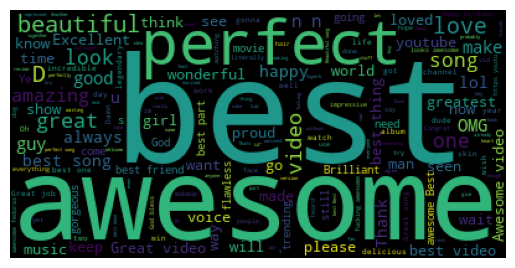

In [34]:
plt.imshow(wordcloud)
plt.axis('off')

### **What I found:**
- positive Users are emphasizing more on best , awesome , perfect , amazing , look , happy  etc..


In [35]:
total_comments_negative = ' '.join(comments_negative['comment_text'])

In [36]:
wordcloud2 = WordCloud(stopwords=set(STOPWORDS)).generate(total_comments_negative)

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

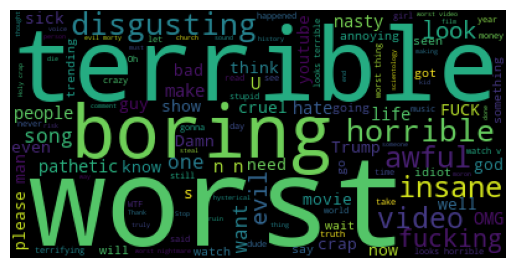

In [37]:
plt.imshow(wordcloud2)
plt.axis('off')

### **What I found:**
- Negative Users are emphasizing more on Terrible , worst ,horrible ,boring , disgusting etc..


## 4. Finding the most common emojis


Next, I want to find out which emojis people use most in the comments.
We will extract emojis from all comments, count how many times each emoji appears, and make a bar chart using Plotly to show the top 10 emojis.


### **Emoji Analysis**
People use a lot of emojis on YouTube! I want to find out which emojis are the most popular.
To do this, I will write a simple loop to extract emojis from the comments using the `emoji` library, count how often each one appears, and make an interactive bar chart using **Plotly**.


### **Overview**
Emojis are a crucial, non-verbal channel of communication carrying dense sentiment signals. In this section, we parse individual comments, extract emojis using the `emoji` package, and track their frequencies. Finally, we visualize the Top 10 most common emojis using an interactive **Plotly** bar chart.


In [38]:
!pip install emoji==2.2.0 ## 2.2.0 is a most stable version till date , hence installing this version makes sense !


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '##': Expected package name at the start of dependency specifier
    ##
    ^


In [39]:
import emoji

In [40]:
emoji.__version__

'2.15.0'

In [41]:
comments['comment_text'].head(6)

0                    Logan Paul it's yo big day ‼️‼️‼️
1    I've been following you from the start of your...
2                   Say hi to Kong and maverick for me
3                                  MY FAN . attendance
4                                           trending 😉
5                              #1 on trending AYYEEEEE
Name: comment_text, dtype: object

In [42]:
### lets extract emoji from below comment

In [43]:
comment = 'trending 😉'

In [44]:
[char for char in comment if char in emoji.EMOJI_DATA]

['😉']

In [45]:
## lets try to write above code in a more simpler & readable way :

In [46]:
emoji_list = []

for char in comment:
    if char in emoji.EMOJI_DATA:
        emoji_list.append(char)

In [47]:
emoji_list

['😉']

In [48]:
all_emojis_list = []

for comment in comments['comment_text'].dropna(): ## in case u have missing values , call dropna()
    for char in comment:
        if char in emoji.EMOJI_DATA:
            all_emojis_list.append(char)

In [49]:
all_emojis_list[0:10]

['‼', '‼', '‼', '😉', '😭', '👍', '🏻', '❤', '😍', '💋']

In [50]:
### NOw we have to compute frequencies of each & every emoji in "all_emojis_list"..

In [51]:
from collections import Counter

In [52]:
Counter(all_emojis_list).most_common(10)

[('😂', 36987),
 ('😍', 33453),
 ('❤', 31119),
 ('🔥', 8694),
 ('😭', 8398),
 ('👏', 5719),
 ('😘', 5545),
 ('👍', 5476),
 ('💖', 5359),
 ('💕', 5147)]

In [53]:
Counter(all_emojis_list).most_common(10)[0]

('😂', 36987)

In [54]:
Counter(all_emojis_list).most_common(10)[0][0]

'😂'

In [55]:
Counter(all_emojis_list).most_common(10)[1][0]

'😍'

In [56]:
Counter(all_emojis_list).most_common(10)[2][0]

'❤'

In [57]:
emojis = [Counter(all_emojis_list).most_common(10)[i][0] for i in range(10)]

In [58]:
Counter(all_emojis_list).most_common(10)[0][1]

36987

In [59]:
Counter(all_emojis_list).most_common(10)[1][1]

33453

In [60]:
Counter(all_emojis_list).most_common(10)[2][1]

31119

In [61]:
freqs = [Counter(all_emojis_list).most_common(10)[i][1] for i in range(10)]

In [62]:
freqs

[36987, 33453, 31119, 8694, 8398, 5719, 5545, 5476, 5359, 5147]

In [63]:
import plotly.graph_objs as go
from plotly.offline import iplot

In [64]:
trace = go.Bar(x=emojis , y=freqs)

In [65]:
import plotly.offline as pyo
pyo.init_notebook_mode(connected=True)
pyo.iplot([trace])

### **What I found:**
- Majority of the customers are happy as most of them are using emojis like: funny , love , heart , outstanding..


## 5. Joining YouTube data from different countries


The YouTube trending video data is split into different CSV files for each country.
I want to put them all together into one table so we can analyze all of them at once. I will read all the CSV files from our `additional_data` folder and combine them.


### **Consolidating the Datasets**
The trending video data is split into different CSV files for each country (like US, Canada, Great Britain, Germany).
To do a bigger analysis, I am going to read all the CSV files from our `additional_data` folder and combine them into one big dataframe using `pd.concat`!


### **Overview**
The trending videos dataset is separated by region (e.g., US, CA, GB, DE). To execute global-scale analyses, we search the `additional_data` folder, extract all country CSV files, and concatenate them into a single unified dataframe.


In [66]:
import os

In [67]:
files= os.listdir(r'./additional_data')

In [68]:
files

['CAvideos.csv',
 'CA_category_id.json',
 'DEvideos.csv',
 'DE_category_id.json',
 'FRvideos.csv',
 'FR_category_id.json',
 'GBvideos.csv',
 'GB_category_id.json',
 'INvideos.csv',
 'IN_category_id.json',
 'JPvideos.csv',
 'JP_category_id.json',
 'KRvideos.csv',
 'KR_category_id.json',
 'MXvideos.csv',
 'MX_category_id.json',
 'RUvideos.csv',
 'RU_category_id.json',
 'USvideos.csv',
 'US_category_id.json']

In [69]:
## extracting csv files only from above list ..

files_csv = [file for file in files if '.csv' in file]

In [70]:
files_csv

['CAvideos.csv',
 'DEvideos.csv',
 'FRvideos.csv',
 'GBvideos.csv',
 'INvideos.csv',
 'JPvideos.csv',
 'KRvideos.csv',
 'MXvideos.csv',
 'RUvideos.csv',
 'USvideos.csv']

In [71]:
import warnings
from warnings import filterwarnings
filterwarnings('ignore')

#### different types of encoding-->>
    Note : encoding may change depending upon data  , country data , sometimes regional data as well.
    Fore more inforation on Encoding -- Follow below
### https://docs.python.org/3/library/codecs.html#standard-encodings¶

In [72]:
full_df = pd.DataFrame()
path = r'./additional_data'


for file in files_csv:
    current_df = pd.read_csv(path+'/'+file , encoding='iso-8859-1' , on_bad_lines='skip')
    
    full_df = pd.concat([full_df , current_df] , ignore_index=True)

In [73]:
full_df.shape

(375942, 16)

## 6. Saving the combined data


Now that the data is clean and combined, I will save a small sample of it (first 1000 rows) as a CSV, JSON, and a SQLite database file so we can open it easily in other software.


### **Saving Our Work**
Now that the data is combined and cleaned, it's a good practice to export it. I'll save a sample of 1,000 rows into different formats: CSV, JSON, and a SQLite Database using SQLAlchemy. This is super useful if we want to use the data in other tools like Tableau or PowerBI!


### **Overview**
After cleaning and combining our dataset, saving the output in structured formats is critical for downstream BI dashboards (like Tableau/PowerBI). We export a sample of our consolidated dataset to CSV, JSON, and a local SQLite database using SQLAlchemy.


In [74]:
### upto some extent your data is cleaned , so lets export this data into various formats for further analysis :

In [75]:
'''

export your data into :
    a) csv 
    b) json
    c) db


'''

'\n\nexport your data into :\n    a) csv \n    b) json\n    c) db\n\n\n'

In [76]:
full_df[full_df.duplicated()].shape

(36417, 16)

In [77]:
'''
default value of keep='first'

It means that the method will consider the first instance of a row to be unique and the remaining instances to be duplicates.


keep='first' (default): mark all rows as duplicates except for the first occurrence.

keep='last': mark all rows as duplicates except for the last occurrence.

keep=False: mark all rows as all duplicates.


'''

"\ndefault value of keep='first'\n\nIt means that the method will consider the first instance of a row to be unique and the remaining instances to be duplicates.\n\n\nkeep='first' (default): mark all rows as duplicates except for the first occurrence.\n\nkeep='last': mark all rows as duplicates except for the last occurrence.\n\nkeep=False: mark all rows as all duplicates.\n\n\n"

In [78]:
full_df = full_df.drop_duplicates() ## lets drop duplicate rows ..

In [79]:
full_df.shape

(339525, 16)

#### a... Storing data into csv ..

In [80]:
### you can consider sample of data depending on how efficient your system is..

full_df[0:1000].to_csv(r'./export_data/youtube_sample.csv' , index=False)

#### b... Storing data into json

In [81]:
full_df[0:1000].to_json(r'./export_data/youtube_sample.json')

#### c... Storing data into database

In [82]:
#create engine allows us to connect to database
from sqlalchemy import create_engine

In [83]:
# Lets create sql_alchemy engine by using create_engine method ie create engine allows us to connect to database
engine = create_engine(r'sqlite:///./export_data/youtube_sample.sqlite')

In [84]:
### we will store first 1000 rows into Users table..
full_df[0:1000].to_sql('Users' , con=engine , if_exists='append')

1000

In [85]:
## As soon as u have u have your data into 'youtube_sample.sqlite' which has table has 'Users', now u can read data from this db file 'youtube_whole_data.sqlite' using sqlite3 & pandas

## 7. Which categories get the most likes?


Videos in the dataset have category IDs (like 10 or 22). I will load the names of these categories from the JSON file and map them. Then, I will make a boxplot to compare the likes for each category.


### **Mapping Categories**
In the CSV, categories are just numbers (like `10`, `22`). I'll load the category names from the `US_category_id.json` file and map them to our dataframe. Then, we can use boxplots to see which categories get the most likes!


### **Overview**
To understand what types of content resonate most with audiences, we map category IDs to actual category names using the project's metadata JSON file. We then plot the distribution of likes across different categories using Seaborn boxplots.


In [86]:
full_df.head(5)

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,n1WpP7iowLc,17.14.11,Eminem - Walk On Water (Audio) ft. BeyoncÃ©,EminemVEVO,10,2017-11-10T17:00:03.000Z,"Eminem|""Walk""|""On""|""Water""|""Aftermath/Shady/In...",17158579,787425,43420,125882,https://i.ytimg.com/vi/n1WpP7iowLc/default.jpg,False,False,False,Eminem's new track Walk on Water ft. BeyoncÃ© ...
1,0dBIkQ4Mz1M,17.14.11,PLUSH - Bad Unboxing Fan Mail,iDubbbzTV,23,2017-11-13T17:00:00.000Z,"plush|""bad unboxing""|""unboxing""|""fan mail""|""id...",1014651,127794,1688,13030,https://i.ytimg.com/vi/0dBIkQ4Mz1M/default.jpg,False,False,False,STill got a lot of packages. Probably will las...
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146035,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO â¶ \n\nSUBSCRIBE âº ...
3,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095828,132239,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...
4,2Vv-BfVoq4g,17.14.11,Ed Sheeran - Perfect (Official Music Video),Ed Sheeran,10,2017-11-09T11:04:14.000Z,"edsheeran|""ed sheeran""|""acoustic""|""live""|""cove...",33523622,1634130,21082,85067,https://i.ytimg.com/vi/2Vv-BfVoq4g/default.jpg,False,False,False,ð§: https://ad.gt/yt-perfect\nð°: https://...


In [87]:
full_df['category_id'].unique()

array([10, 23, 24, 25, 22, 26,  1, 28, 20, 17, 29, 15, 19,  2, 27, 43, 30,
       44])

In [88]:
## lets read json file ..
json_df = pd.read_json(r'./additional_data/US_category_id.json')

In [89]:
json_df

,kind,etag,items
0,youtube#videoCategoryListResponse,"""m2yskBQFythfE4irbTIeOgYYfBU/S730Ilt-Fi-emsQJv...","{'kind': 'youtube#videoCategory', 'etag': '""m2..."
1,youtube#videoCategoryListResponse,"""m2yskBQFythfE4irbTIeOgYYfBU/S730Ilt-Fi-emsQJv...","{'kind': 'youtube#videoCategory', 'etag': '""m2..."
2,youtube#videoCategoryListResponse,"""m2yskBQFythfE4irbTIeOgYYfBU/S730Ilt-Fi-emsQJv...","{'kind': 'youtube#videoCategory', 'etag': '""m2..."
3,youtube#videoCategoryListResponse,"""m2yskBQFythfE4irbTIeOgYYfBU/S730Ilt-Fi-emsQJv...","{'kind': 'youtube#videoCategory', 'etag': '""m2..."
4,youtube#videoCategoryListResponse,"""m2yskBQFythfE4irbTIeOgYYfBU/S730Ilt-Fi-emsQJv...","{'kind': 'youtube#videoCategory', 'etag': '""m2..."
5,youtube#videoCategoryListResponse,"""m2yskBQFythfE4irbTIeOgYYfBU/S730Ilt-Fi-emsQJv...","{'kind': 'youtube#videoCategory', 'etag': '""m2..."
6,youtube#videoCategoryListResponse,"""m2yskBQFythfE4irbTIeOgYYfBU/S730Ilt-Fi-emsQJv...","{'kind': 'youtube#videoCategory', 'etag': '""m2..."
7,youtube#videoCategoryListResponse,"""m2yskBQFythfE4irbTIeOgYYfBU/S730Ilt-Fi-emsQJv...","{'kind': 'youtube#videoCategory', 'etag': '""m2..."
8,youtube#videoCategoryListResponse,"""m2yskBQFythfE4irbTIeOgYYfBU/S730Ilt-Fi-emsQJv...","{'kind': 'youtube#videoCategory', 'etag': '""m2..."
9,youtube#videoCategoryListResponse,"""m2yskBQFythfE4irbTIeOgYYfBU/S730Ilt-Fi-emsQJv...","{'kind': 'youtube#videoCategory', 'etag': '""m2..."


In [90]:
json_df['items'][0]

### each row of 'Items' feature is dictionary .. 

{'kind': 'youtube#videoCategory',
 'etag': '"m2yskBQFythfE4irbTIeOgYYfBU/Xy1mB4_yLrHy_BmKmPBggty2mZQ"',
 'id': '1',
 'snippet': {'channelId': 'UCBR8-60-B28hp2BmDPdntcQ',
  'title': 'Film & Animation',
  'assignable': True}}

In [91]:
json_df['items'][1]

{'kind': 'youtube#videoCategory',
 'etag': '"m2yskBQFythfE4irbTIeOgYYfBU/UZ1oLIIz2dxIhO45ZTFR3a3NyTA"',
 'id': '2',
 'snippet': {'channelId': 'UCBR8-60-B28hp2BmDPdntcQ',
  'title': 'Autos & Vehicles',
  'assignable': True}}

In [92]:
cat_dict = {}

for item in json_df['items'].values:
    ## cat_dict[key] = value (Syntax to insert key:value in dictionary)
    cat_dict[int(item['id'])] = item['snippet']['title']

In [93]:
cat_dict

{1: 'Film & Animation',
 2: 'Autos & Vehicles',
 10: 'Music',
 15: 'Pets & Animals',
 17: 'Sports',
 18: 'Short Movies',
 19: 'Travel & Events',
 20: 'Gaming',
 21: 'Videoblogging',
 22: 'People & Blogs',
 23: 'Comedy',
 24: 'Entertainment',
 25: 'News & Politics',
 26: 'Howto & Style',
 27: 'Education',
 28: 'Science & Technology',
 29: 'Nonprofits & Activism',
 30: 'Movies',
 31: 'Anime/Animation',
 32: 'Action/Adventure',
 33: 'Classics',
 34: 'Comedy',
 35: 'Documentary',
 36: 'Drama',
 37: 'Family',
 38: 'Foreign',
 39: 'Horror',
 40: 'Sci-Fi/Fantasy',
 41: 'Thriller',
 42: 'Shorts',
 43: 'Shows',
 44: 'Trailers'}

In [94]:
full_df['category_name'] = full_df['category_id'].map(cat_dict)

In [95]:
full_df.head(4)

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,category_name
0,n1WpP7iowLc,17.14.11,Eminem - Walk On Water (Audio) ft. BeyoncÃ©,EminemVEVO,10,2017-11-10T17:00:03.000Z,"Eminem|""Walk""|""On""|""Water""|""Aftermath/Shady/In...",17158579,787425,43420,125882,https://i.ytimg.com/vi/n1WpP7iowLc/default.jpg,False,False,False,Eminem's new track Walk on Water ft. BeyoncÃ© ...,Music
1,0dBIkQ4Mz1M,17.14.11,PLUSH - Bad Unboxing Fan Mail,iDubbbzTV,23,2017-11-13T17:00:00.000Z,"plush|""bad unboxing""|""unboxing""|""fan mail""|""id...",1014651,127794,1688,13030,https://i.ytimg.com/vi/0dBIkQ4Mz1M/default.jpg,False,False,False,STill got a lot of packages. Probably will las...,Comedy
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146035,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO â¶ \n\nSUBSCRIBE âº ...,Comedy
3,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095828,132239,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...,Entertainment


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17],
 [Text(0, 0, 'Music'),
  Text(1, 0, 'Comedy'),
  Text(2, 0, 'Entertainment'),
  Text(3, 0, 'News & Politics'),
  Text(4, 0, 'People & Blogs'),
  Text(5, 0, 'Howto & Style'),
  Text(6, 0, 'Film & Animation'),
  Text(7, 0, 'Science & Technology'),
  Text(8, 0, 'Gaming'),
  Text(9, 0, 'Sports'),
  Text(10, 0, 'Nonprofits & Activism'),
  Text(11, 0, 'Pets & Animals'),
  Text(12, 0, 'Travel & Events'),
  Text(13, 0, 'Autos & Vehicles'),
  Text(14, 0, 'Education'),
  Text(15, 0, 'Shows'),
  Text(16, 0, 'Movies'),
  Text(17, 0, 'Trailers')])

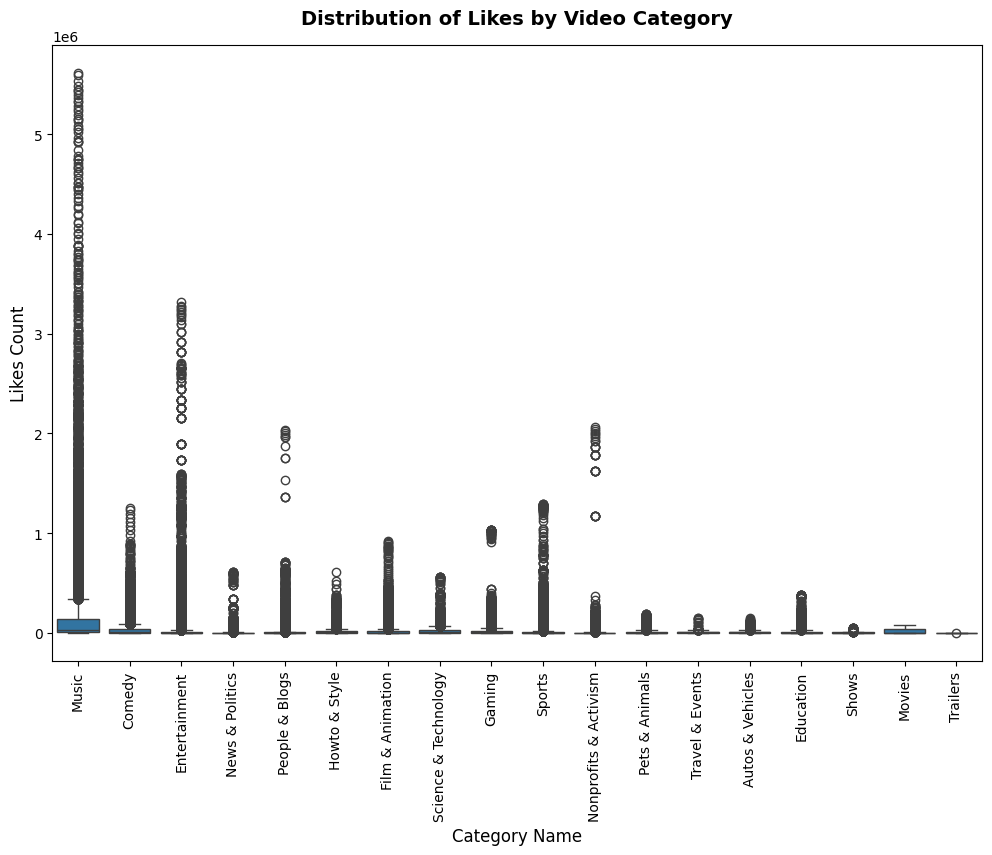

In [96]:
plt.figure(figsize=(12,8))
sns.boxplot(x='category_name' , y='likes' , data=full_df)
plt.title('Distribution of Likes by Video Category', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Category Name', fontsize=12)
plt.ylabel('Likes Count', fontsize=12)
plt.xticks(rotation='vertical')

## 8. Analyzing views, likes, and dislikes


I want to see if videos with more views also get more likes and dislikes. I will create a scatter plot with a regression line and a correlation heatmap to see how closely they are related.


### **Analyzing Correlation**
Let's see if there is a relationship between how many views a video gets and how many likes/dislikes it receives. I will create a regression plot and a correlation heatmap to visualize these relationships.


### **Overview**
Engagement is more than just raw views; it is about the ratio of likes, dislikes, and comments. We calculate user engagement rates (`like_rate`) and use regression plots and correlation heatmaps to study the relationship between Views, Likes, and Dislikes.


In [97]:
full_df['like_rate'] = (full_df['likes']/full_df['views'])*100
full_df['dislike_rate'] = (full_df['dislikes']/full_df['views'])*100
full_df['comment_count_rate'] = (full_df['comment_count']/full_df['views'])*100

In [98]:
full_df.columns

Index(['video_id', 'trending_date', 'title', 'channel_title', 'category_id',
       'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count',
       'thumbnail_link', 'comments_disabled', 'ratings_disabled',
       'video_error_or_removed', 'description', 'category_name', 'like_rate',
       'dislike_rate', 'comment_count_rate'],
      dtype='object')

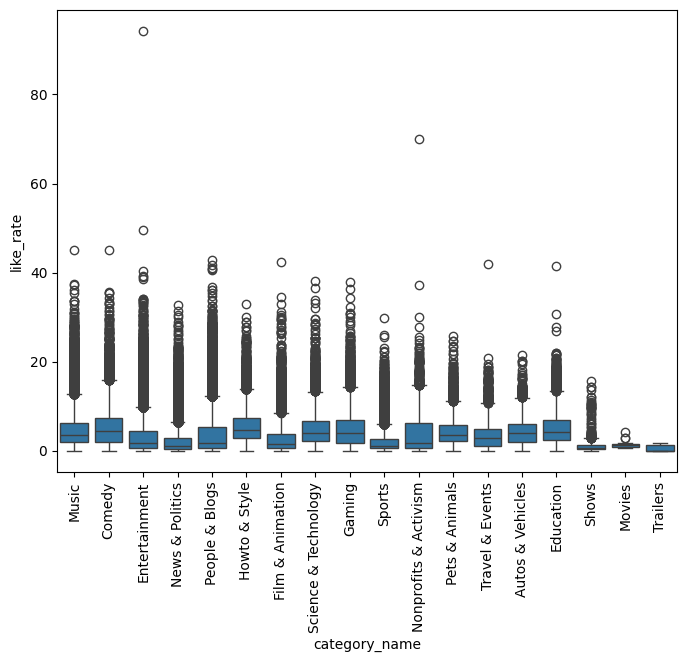

In [99]:
plt.figure(figsize=(8,6))
sns.boxplot(x='category_name' , y='like_rate' , data=full_df)
plt.xticks(rotation='vertical')
plt.show()

In [100]:
### analysing relationship between views & likes

<Axes: xlabel='views', ylabel='likes'>

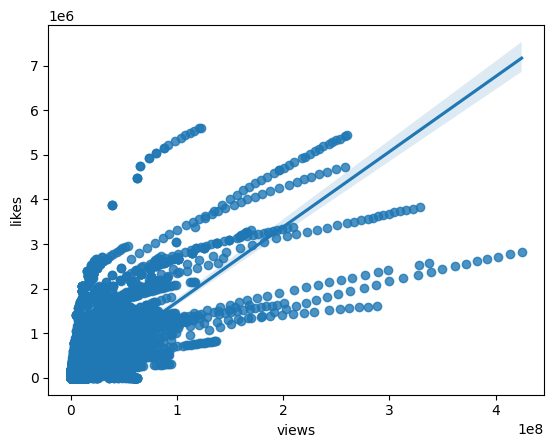

In [101]:
sns.regplot(x='views' , y='likes' , data = full_df)

In [102]:
full_df.columns

Index(['video_id', 'trending_date', 'title', 'channel_title', 'category_id',
       'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count',
       'thumbnail_link', 'comments_disabled', 'ratings_disabled',
       'video_error_or_removed', 'description', 'category_name', 'like_rate',
       'dislike_rate', 'comment_count_rate'],
      dtype='object')

In [103]:
full_df[['views', 'likes', 'dislikes']].corr() ### finding co-relation values between ['views', 'likes', 'dislikes']

,views,likes,dislikes
views,1.000000,0.779531,0.405428
likes,0.779531,1.000000,0.451809
dislikes,0.405428,0.451809,1.000000


Text(0.5, 1.0, 'Correlation Heatmap: Views, Likes & Dislikes')

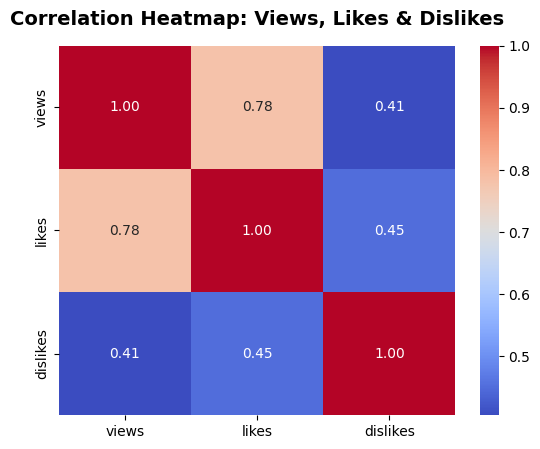

In [104]:
sns.heatmap(full_df[['views', 'likes', 'dislikes']].corr() , annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap: Views, Likes & Dislikes', fontsize=14, fontweight='bold', pad=15)

## 9. Which channels have the most trending videos?


We will count how many times each channel name appears in the trending list and plot the top 20 channels.


### **Finding Top Channels**
I want to know which creators are consistently trending. I'll count how many times each channel appears in our dataset and plot the top 20 channels using Plotly!


### **Overview**
Consistent viewership is key for content creators. In this section, we group the dataset by channel title to find the creators that make it onto the trending list most frequently, and visualize them using a Plotly bar chart.


In [105]:
full_df.head(6)

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,category_name,like_rate,dislike_rate,comment_count_rate
0,n1WpP7iowLc,17.14.11,Eminem - Walk On Water (Audio) ft. BeyoncÃ©,EminemVEVO,10,2017-11-10T17:00:03.000Z,"Eminem|""Walk""|""On""|""Water""|""Aftermath/Shady/In...",17158579,787425,43420,125882,https://i.ytimg.com/vi/n1WpP7iowLc/default.jpg,False,False,False,Eminem's new track Walk on Water ft. BeyoncÃ© ...,Music,4.589104,0.253051,0.733639
1,0dBIkQ4Mz1M,17.14.11,PLUSH - Bad Unboxing Fan Mail,iDubbbzTV,23,2017-11-13T17:00:00.000Z,"plush|""bad unboxing""|""unboxing""|""fan mail""|""id...",1014651,127794,1688,13030,https://i.ytimg.com/vi/0dBIkQ4Mz1M/default.jpg,False,False,False,STill got a lot of packages. Probably will las...,Comedy,12.594873,0.166363,1.284185
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146035,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO â¶ \n\nSUBSCRIBE âº ...,Comedy,4.575843,0.167292,0.256342
3,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095828,132239,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...,Entertainment,6.309630,0.094903,0.835851
4,2Vv-BfVoq4g,17.14.11,Ed Sheeran - Perfect (Official Music Video),Ed Sheeran,10,2017-11-09T11:04:14.000Z,"edsheeran|""ed sheeran""|""acoustic""|""live""|""cove...",33523622,1634130,21082,85067,https://i.ytimg.com/vi/2Vv-BfVoq4g/default.jpg,False,False,False,ð§: https://ad.gt/yt-perfect\nð°: https://...,Music,4.874563,0.062887,0.253752
5,0yIWz1XEeyc,17.14.11,Jake Paul Says Alissa Violet CHEATED with LOGA...,DramaAlert,25,2017-11-13T07:37:51.000Z,"#DramaAlert|""Drama""|""Alert""|""DramaAlert""|""keem...",1309699,103755,4613,12143,https://i.ytimg.com/vi/0yIWz1XEeyc/default.jpg,False,False,False,âº Follow for News! - https://twitter.com/KEE...,News & Politics,7.922049,0.352218,0.927160


In [106]:
full_df['channel_title'].value_counts()

channel_title
The Late Show with Stephen Colbert    710
WWE                                   643
Late Night with Seth Meyers           592
TheEllenShow                          555
Jimmy Kimmel Live                     528
                                     ... 
The Secrets of Dairy                    1
babygranderecords                       1
24 Oras News Today                      1
turk2doubleoh8                          1
BOOMPANOT.COM                           1
Name: count, Length: 37824, dtype: int64

In [107]:
### lets obtain above frequency table using groupby approach : 

In [108]:
cdf = full_df.groupby(['channel_title']).size().sort_values(ascending=False).reset_index()

In [109]:
cdf = cdf.rename(columns={0:'total_videos'})

In [110]:
cdf

,channel_title,total_videos
0,The Late Show with Stephen Colbert,710
1,WWE,643
2,Late Night with Seth Meyers,592
3,TheEllenShow,555
4,Jimmy Kimmel Live,528
...,...,...
37819,Tesoros Enterrados,1
37820,Anton Neverov,1
37821,Thalia 444,1
37822,Thaitv6 Official,1


In [111]:
import plotly.express as px

In [112]:
px.bar(data_frame=cdf[0:20] , x='channel_title' , y='total_videos')

## 10. Does title punctuation affect views and likes?


Does using exclamation marks or question marks in the title help get more views? I will count how many punctuation marks are in the titles and plot them against views and likes to see if there is any pattern.


### **Testing a Hypothesis**
Do clickbait titles with lots of punctuation (like exclamation marks or question marks) actually get more views?
Let's write a python function to count punctuation marks in video titles, apply it to a sample of 10,000 videos, and use boxplots to check!


### **Overview**
Is there a link between punctuation (e.g., exclamation marks, capital letters) in titles and audience click-through rate? We count punctuation marks in video titles and use boxplots to check if titles with more punctuation attract more views or likes.


In [113]:
full_df['title'][0]

'Eminem - Walk On Water (Audio) ft. BeyoncÃ©'

In [114]:
import string

In [115]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [116]:
len([char for char in full_df['title'][0] if char in string.punctuation])

4

In [117]:
def punc_count(text):
    return len([char for char in text if char in string.punctuation])

In [118]:
sample = full_df[0:10000]

In [119]:
sample['count_punc'] = sample['title'].apply(punc_count)

In [120]:
sample['count_punc']

0       4
1       1
2       3
3       3
4       3
       ..
9995    6
9996    0
9997    1
9998    0
9999    6
Name: count_punc, Length: 10000, dtype: int64

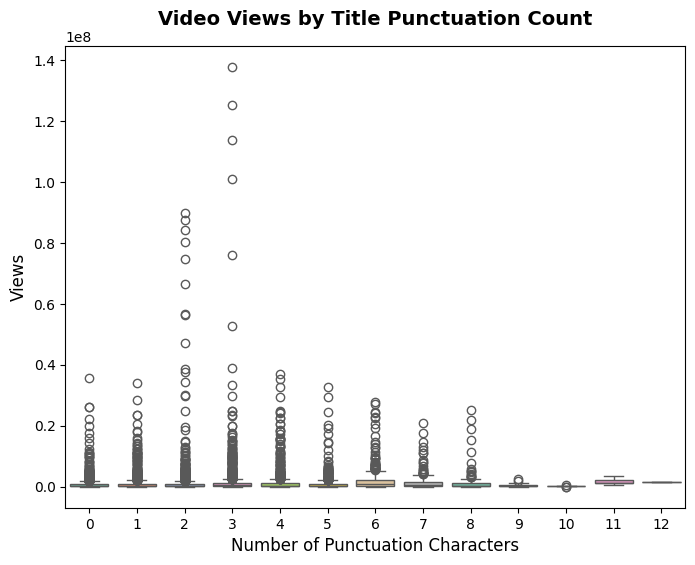

In [121]:
plt.figure(figsize=(8,6))
sns.boxplot(x='count_punc' , y='views' , data=sample, palette='Set2')
plt.title('Video Views by Title Punctuation Count', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Punctuation Characters', fontsize=12)
plt.ylabel('Views', fontsize=12)
plt.show()

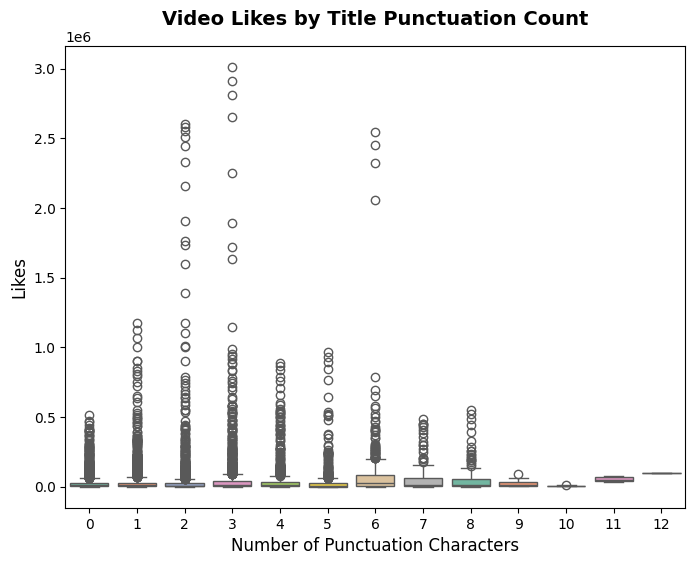

In [122]:
plt.figure(figsize=(8,6))
sns.boxplot(x='count_punc' , y='likes' , data=sample, palette='Set2')
plt.title('Video Likes by Title Punctuation Count', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Punctuation Characters', fontsize=12)
plt.ylabel('Likes', fontsize=12)
plt.show()

## 11. Summary of my findings

### **What I found out:**

After finishing this analysis, here are the main conclusions I got from the data:

- **Comments and Feelings:** Most comments are positive. The most popular words people write are 'best' and 'awesome'.
- **Emojis:** The laughing emoji 😂 and heart emojis ❤️ / 😍 are used the most by far.
- **Popular Categories:** Music and Entertainment videos get the highest number of views and likes.
- **Views and Likes:** There is a very strong relationship between views and likes. If a video gets more views, it almost always gets more likes.
- **Title Punctuation:** Titles with 1 to 4 punctuation marks (like ! or ?) get the most views. Titles with no punctuation or too many marks get fewer views.
